# Feature Engineering Analysis
Evaluate feature importance, distributions, and correlations.
Select final features for online ML model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv('D:/Data Science/ML_Projects/Production_ready_ML_project/data/features/btc_features.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Correct metadata columns
meta_cols = ['timestamp', 'open', 'high', 'low', 
             'close', 'volume', 'future_return', 'crash']

# FIX: exclude future_return from features
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f"Dataset shape:   {df.shape}")
print(f"ML features:     {len(feature_cols)}")
print(f"Crashes:         {df['crash'].sum()} ({df['crash'].mean()*100:.2f}%)")
print(f"Date range:      {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"\nFeature list:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {f}")

C:\Users\Sweety\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


Dataset shape:   (17197, 37)
ML features:     29
Crashes:         367 (2.13%)
Date range:      2026-05-16 02:15:00 → 2026-07-14 20:15:00

Feature list:
   1. price_change_3c
   2. price_change_6c
   3. price_change_12c
   4. price_change_24c
   5. price_momentum
   6. price_acceleration
   7. hl_spread
   8. dist_from_high
   9. volatility_3c
  10. volatility_6c
  11. volatility_12c
  12. volatility_ratio
  13. volatility_change
  14. volume_spike
  15. volume_log
  16. rsi_14
  17. macd_hist
  18. bb_position
  19. bb_width
  20. hour_sin
  21. hour_cos
  22. dow_sin
  23. dow_cos
  24. is_us_market
  25. is_asian_hours
  26. volatility_3c_lag1
  27. volatility_3c_lag3
  28. price_change_6c_lag1
  29. price_change_6c_lag3


X shape: (17197, 29)
y crash rate: 2.13%

Training Random Forest for feature importance...


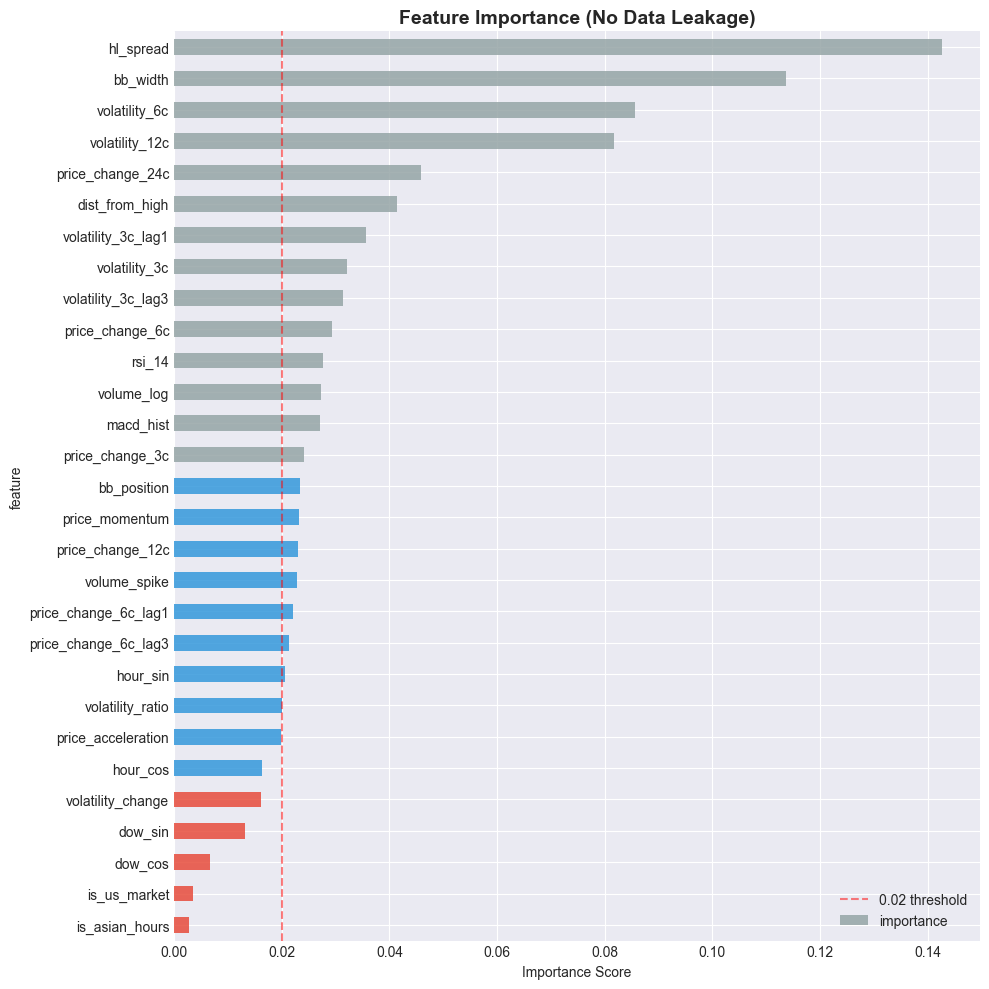


Top 10 Features:
              feature  importance
0           hl_spread    0.142593
1            bb_width    0.113592
2       volatility_6c    0.085666
3      volatility_12c    0.081705
4    price_change_24c    0.045909
5      dist_from_high    0.041332
6  volatility_3c_lag1    0.035666
7       volatility_3c    0.032076
8  volatility_3c_lag3    0.031333
9     price_change_6c    0.029313

Bottom 5 Features (candidates to drop):
              feature  importance
24  volatility_change    0.016054
25            dow_sin    0.013134
26            dow_cos    0.006710
27       is_us_market    0.003496
28     is_asian_hours    0.002668


In [2]:
X = df[feature_cols].fillna(0)
y = df['crash']

print(f"X shape: {X.shape}")
print(f"y crash rate: {y.mean()*100:.2f}%")
print("\nTraining Random Forest for feature importance...")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',   # handle imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if i < 5 else '#3498db' if i < 15 else '#95a5a6' 
          for i in range(len(feature_cols))]
feature_importance.plot(
    x='feature', y='importance', 
    kind='barh', ax=ax,
    color=colors[::-1], alpha=0.85
)
ax.set_title('Feature Importance (No Data Leakage)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
ax.axvline(x=0.02, color='red', linestyle='--', 
           alpha=0.5, label='0.02 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('D:/Data Science/ML_Projects/Production_ready_ML_project/docs/feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string())

print("\nBottom 5 Features (candidates to drop):")
print(feature_importance.tail(5).to_string())

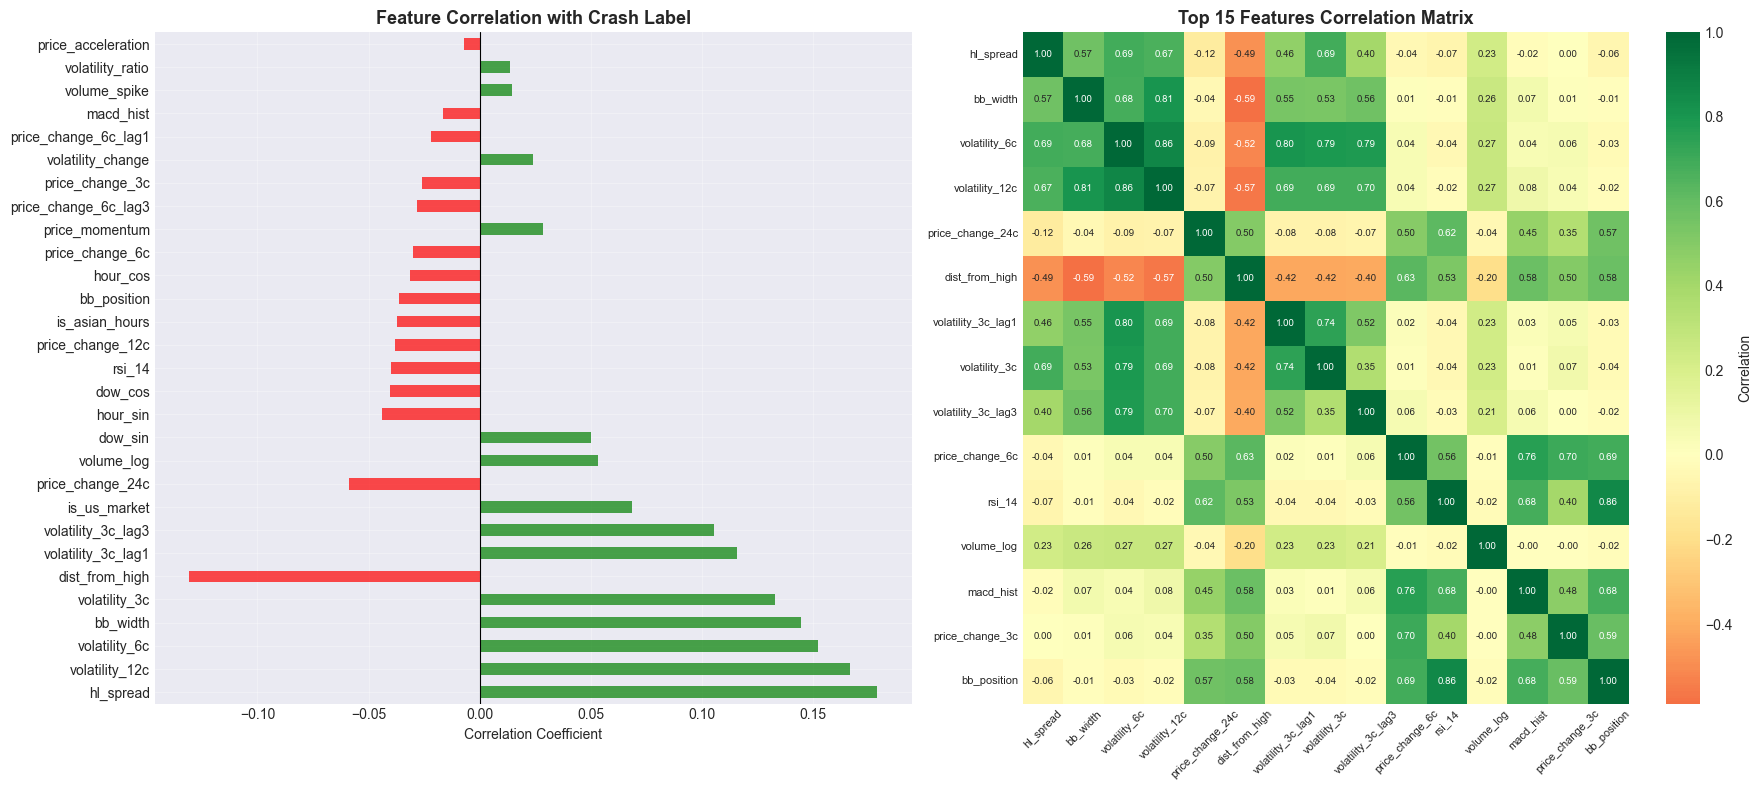


Top 10 features by correlation with crash:
hl_spread             0.1790
volatility_12c        0.1668
volatility_6c         0.1523
bb_width              0.1446
volatility_3c         0.1331
dist_from_high        0.1308
volatility_3c_lag1    0.1157
volatility_3c_lag3    0.1057
is_us_market          0.0685
price_change_24c      0.0587


In [3]:
# Correlation between features and crash
corr_with_crash = df[feature_cols + ['crash']].corr()['crash'].drop('crash')
corr_sorted = corr_with_crash.abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Correlation with crash target
corr_with_crash.reindex(corr_sorted.index).plot(
    kind='barh', ax=axes[0],
    color=['red' if x < 0 else 'green' for x in 
           corr_with_crash.reindex(corr_sorted.index)],
    alpha=0.7
)
axes[0].set_title('Feature Correlation with Crash Label', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Feature correlation heatmap (top 15 only for readability)
top_features = feature_importance.head(15)['feature'].tolist()
corr_matrix = df[top_features].corr()

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=axes[1],
    cbar_kws={'label': 'Correlation'},
    annot_kws={'size': 7}
)
axes[1].set_title('Top 15 Features Correlation Matrix', 
                  fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('D:/Data Science/ML_Projects/Production_ready_ML_project/docs/feature_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features by correlation with crash:")
print(corr_sorted.head(10).round(4).to_string())

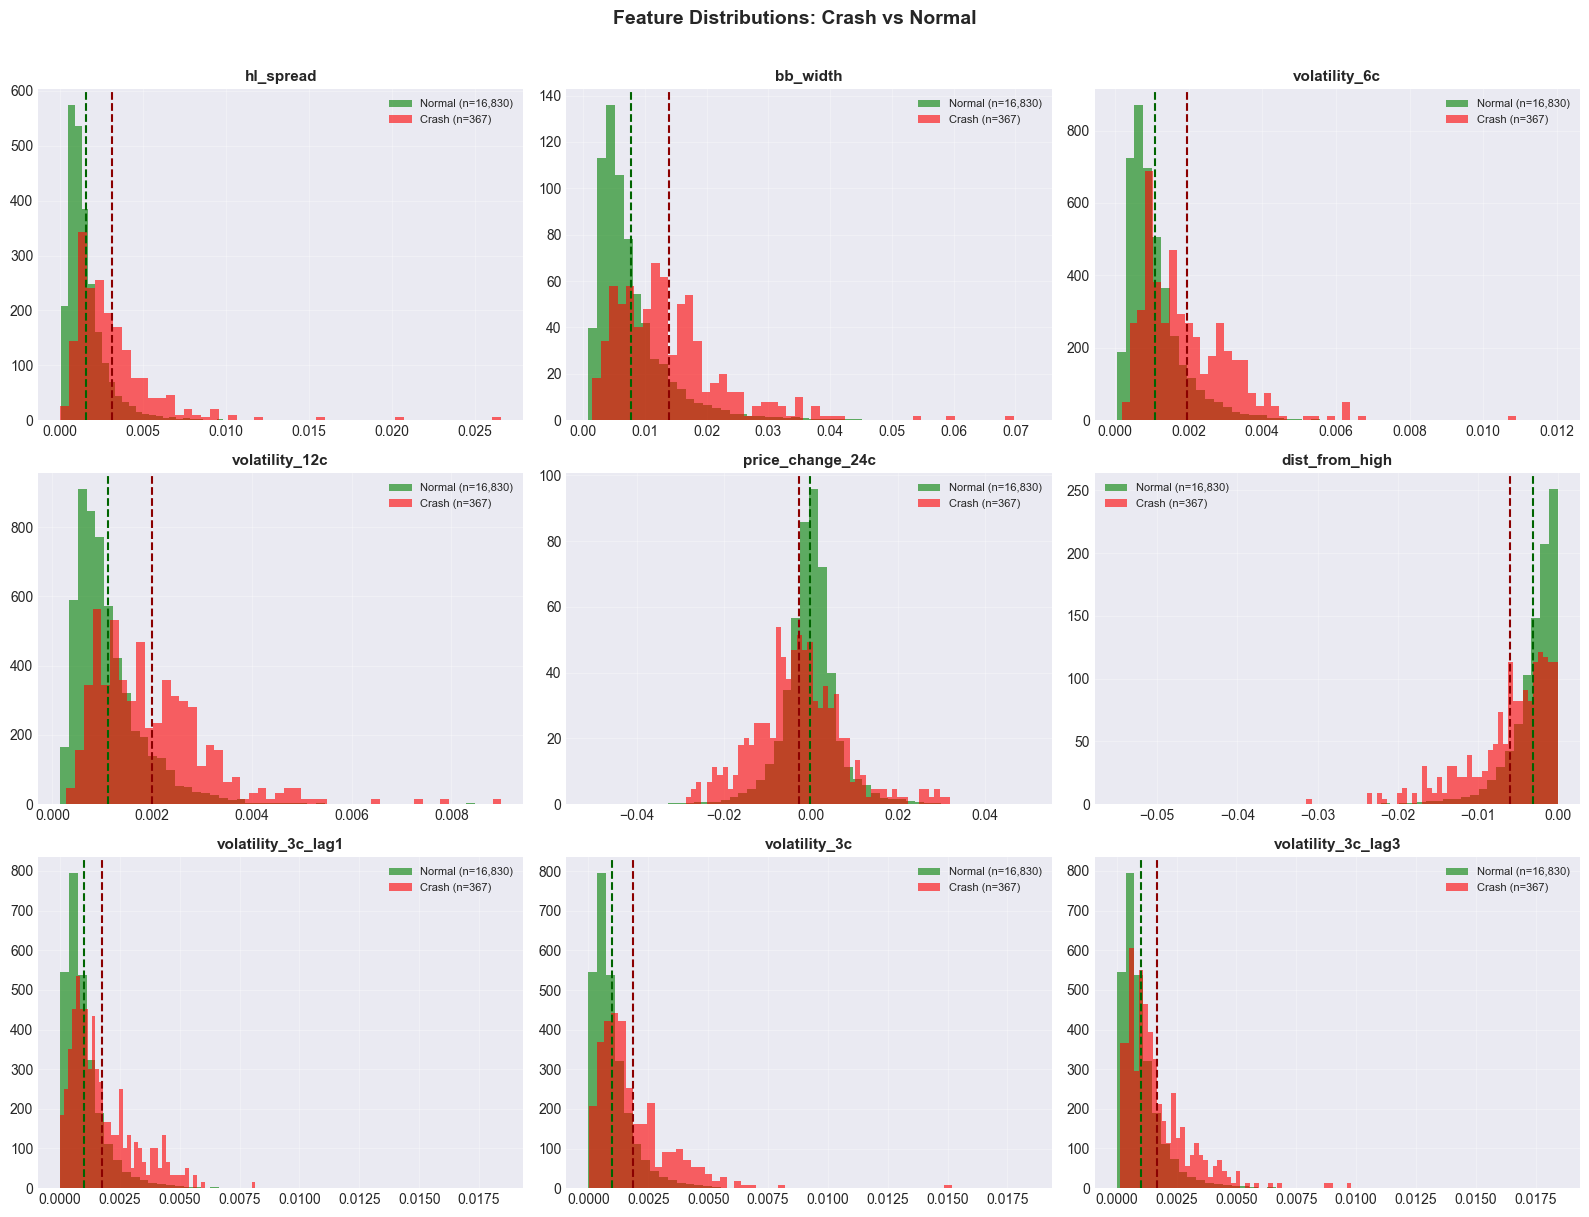

In [4]:
# Show top 9 features (excluding future_return)
top9 = feature_importance.head(9)['feature'].values

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(top9):
    normal_vals = df[df['crash']==0][feature].dropna()
    crash_vals  = df[df['crash']==1][feature].dropna()
    
    axes[idx].hist(normal_vals, bins=50, alpha=0.6,
                   label=f'Normal (n={len(normal_vals):,})', 
                   color='green', density=True)
    axes[idx].hist(crash_vals, bins=50, alpha=0.6,
                   label=f'Crash (n={len(crash_vals):,})',
                   color='red', density=True)
    
    # Add mean lines
    axes[idx].axvline(normal_vals.mean(), color='darkgreen', 
                      linestyle='--', linewidth=1.5)
    axes[idx].axvline(crash_vals.mean(), color='darkred', 
                      linestyle='--', linewidth=1.5)
    
    axes[idx].set_title(feature, fontsize=11, fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Feature Distributions: Crash vs Normal', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('D:/Data Science/ML_Projects/Production_ready_ML_project/docs/feature_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Drop features with very low importance
threshold = 0.02
keep = feature_importance[feature_importance['importance'] >= threshold]['feature'].tolist()
drop = feature_importance[feature_importance['importance'] < threshold]['feature'].tolist()

print("="*55)
print("FEATURE SELECTION DECISION")
print("="*55)
print(f"\n✅ KEEP ({len(keep)} features, importance >= {threshold}):")
for f in keep:
    imp = feature_importance[feature_importance['feature']==f]['importance'].values[0]
    print(f"   {f:30s} {imp:.4f}")

print(f"\n❌ DROP ({len(drop)} features, importance < {threshold}):")
for f in drop:
    imp = feature_importance[feature_importance['feature']==f]['importance'].values[0]
    print(f"   {f:30s} {imp:.4f}")

print(f"\n→ Final feature count for modeling: {len(keep)}")

FEATURE SELECTION DECISION

✅ KEEP (22 features, importance >= 0.02):
   hl_spread                      0.1426
   bb_width                       0.1136
   volatility_6c                  0.0857
   volatility_12c                 0.0817
   price_change_24c               0.0459
   dist_from_high                 0.0413
   volatility_3c_lag1             0.0357
   volatility_3c                  0.0321
   volatility_3c_lag3             0.0313
   price_change_6c                0.0293
   rsi_14                         0.0277
   volume_log                     0.0273
   macd_hist                      0.0271
   price_change_3c                0.0241
   bb_position                    0.0234
   price_momentum                 0.0232
   price_change_12c               0.0230
   volume_spike                   0.0227
   price_change_6c_lag1           0.0221
   price_change_6c_lag3           0.0213
   hour_sin                       0.0206
   volatility_ratio               0.0201

❌ DROP (7 features, importa

In [6]:
import json, os

# Save final selected features
os.makedirs('D:/Data Science/ML_Projects/Production_ready_ML_project/configs', 
            exist_ok=True)

config = {
    'all_features': feature_cols,          # all 29
    'selected_features': keep,             # after importance filter
    'dropped_features': drop,
    'crash_rate': float(df['crash'].mean()),
    'total_rows': len(df),
    'candle_interval': '5min',
    'crash_definition': '-0.5% drop in 15 minutes (3 candles)'
}

config_path = 'D:/Data Science/ML_Projects/Production_ready_ML_project/configs/features.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"✅ Feature config saved to: {config_path}")
print(f"\n{'='*55}")
print("SUMMARY")
print(f"{'='*55}")
print(f"Total features engineered:  {len(feature_cols)}")
print(f"Selected for modeling:       {len(keep)}")
print(f"Dropped (low importance):    {len(drop)}")
print(f"Training rows:               {len(df):,}")
print(f"Crash rate:                  {df['crash'].mean()*100:.2f}%")
print(f"\n✅ Ready for Phase 4: Modeling (04_modeling.ipynb)")

✅ Feature config saved to: D:/Data Science/ML_Projects/Production_ready_ML_project/configs/features.json

SUMMARY
Total features engineered:  29
Selected for modeling:       22
Dropped (low importance):    7
Training rows:               17,197
Crash rate:                  2.13%

✅ Ready for Phase 4: Modeling (04_modeling.ipynb)
